---
Machine Learning con PySpark y Docker

---


PARCIAL FINAL · Componente práctico


# Bloque 1 · Análisis exploratorio con PySpark

In [19]:
# /////////// librerias y dependencias ///////////
!pip install pyspark
from pyspark.sql import SparkSession
from google.colab import files

In [20]:
# /////////// Carga de datos ///////////
spark = SparkSession.builder \
    .appName("LeerCSV") \
    .getOrCreate()

uploaded = files.upload()

df = spark.read.csv(
    "rips_200k_departamento.csv",
    header=True,
    inferSchema=True,
    sep=",",
    encoding="utf-8"
)



Saving rips_200k_departamento.csv to rips_200k_departamento (6).csv


## 1.1 Cargar el dataset elegido con PySpark, mostrando el esquema, conteo de registros y primeras filas.


In [21]:
# EDA

print("\n" + "="*60)
print("INFORMACIÓN GENERAL DEL DATASET RIPS")
print("="*60)

# shape
filas = df.count()
columnas = len(df.columns)

print(f"\n Total de registros : {filas:,}")
print(f"Total de columnas  : {columnas}")

print("\n Nombres de columnas:")
for i, c in enumerate(df.columns, 1):
    print(f"   {i}. {c}")

# estructura


print("\n" + "="*60)
print("ESQUEMA Y TIPOS DE DATOS")
print("="*60)

df.printSchema()

# vista previa


print("\n" + "="*60)
print("PRIMERAS FILAS DEL DATASET")
print("="*60)

df.show(5, truncate=False)

# Resultado


print("\n" + "="*60)
print("RESUMEN DE EXPLORACIÓN")
print("="*60)





INFORMACIÓN GENERAL DEL DATASET RIPS

 Total de registros : 200,000
Total de columnas  : 6

 Nombres de columnas:
   1. departamento
   2. municipio
   3. a_o
   4. tipoatencion
   5. diagnostico
   6. numeroatenciones

ESQUEMA Y TIPOS DE DATOS
root
 |-- departamento: string (nullable = true)
 |-- municipio: string (nullable = true)
 |-- a_o: integer (nullable = true)
 |-- tipoatencion: string (nullable = true)
 |-- diagnostico: string (nullable = true)
 |-- numeroatenciones: integer (nullable = true)


PRIMERAS FILAS DEL DATASET
+--------------+--------------------+----+-----------------------+--------------------------------------------------------------------------------+----------------+
|departamento  |municipio           |a_o |tipoatencion           |diagnostico                                                                     |numeroatenciones|
+--------------+--------------------+----+-----------------------+-------------------------------------------------------------------

# 1.2  Aplicar al menos tres transformaciones (filter, groupBy, withColumn, join) que respondan apreguntas analíticas concretas.


## 1.2.1 **¿Qué municipios presentan más de 100 atenciones registradas?**

In [23]:
from pyspark.sql.functions import *

print("\n" + "="*70)
print("MUNICIPIOS CON MÁS DE 100 ATENCIONES")
print("="*70)

df_altas = df.filter(col("numeroatenciones") > 100)

print(f"Registros encontrados: {df_altas.count()}")

df_altas.select(
    "departamento",
    "municipio",
    "numeroatenciones"
).show(10, truncate=False)


MUNICIPIOS CON MÁS DE 100 ATENCIONES
Registros encontrados: 11543
+-----------------+---------------------+----------------+
|departamento     |municipio            |numeroatenciones|
+-----------------+---------------------+----------------+
|11 - Bogotá, D.C.|11001 - Bogotá, D.C. |509             |
|13 - Bolívar     |13894 - Zambrano     |105             |
|05 - Antioquia   |05001 - Medellín     |207             |
|23 - Córdoba     |23660 - Sahagún      |304             |
|05 - Antioquia   |05001 - Medellín     |394             |
|05 - Antioquia   |05697 - El Santuario |225             |
|05 - Antioquia   |05147 - Carepa       |49973           |
|15 - Boyacá      |15500 - Oicatá       |106             |
|15 - Boyacá      |15572 - Puerto Boyacá|1403            |
|11 - Bogotá, D.C.|11001 - Bogotá, D.C. |5129            |
+-----------------+---------------------+----------------+
only showing top 10 rows


**Se evidencia que la concentración de atenciones se centra en ciudades principales, lo que guarda realción con la cobertura del sistema de salud nacional.**

# 1.2.2 **¿Qué departamentos concentran la mayor cantidad de atenciones?**

In [24]:
print("\n" + "="*70)
print("TOTAL DE ATENCIONES POR DEPARTAMENTO")
print("="*70)

depto_group = df.groupBy("departamento") \
    .agg(
        sum("numeroatenciones").alias("total_atenciones")
    ) \
    .orderBy(col("total_atenciones").desc())

depto_group.show(truncate=False)


TOTAL DE ATENCIONES POR DEPARTAMENTO
+-----------------+----------------+
|departamento     |total_atenciones|
+-----------------+----------------+
|05 - Antioquia   |7301551         |
|11 - Bogotá, D.C.|6516087         |
|08 - Atlántico   |2572869         |
|13 - Bolívar     |1370007         |
|20 - Cesar       |1258819         |
|23 - Córdoba     |1176470         |
|-1 - NO DEFINIDO |1082126         |
|15 - Boyacá      |827623          |
|19 - Cauca       |748649          |
|17 - Caldas      |481641          |
|25 - Cundinamarca|263077          |
|18 - Caquetá     |192228          |
+-----------------+----------------+



**Antioquia y Bogotá D.C. concentran la mayor cantidad de atenciones médicas, lo que refleja una alta demanda de servicios de salud y diferencias regionales importantes frente a otros departamentos.**

# 1.2.3 **¿Cómo clasificar el volumen de atención médica?**

In [25]:
print("\n" + "="*70)
print("CLASIFICACIÓN DEL NIVEL DE ATENCIÓN")
print("="*70)

df_nuevo = df.withColumn(
    "nivel_atencion",
    when(col("numeroatenciones") >= 100, "ALTA")
    .when(col("numeroatenciones") >= 50, "MEDIA")
    .otherwise("BAJA")
)

df_nuevo.select(
    "departamento",
    "municipio",
    "numeroatenciones",
    "nivel_atencion"
).show(15, truncate=False)


CLASIFICACIÓN DEL NIVEL DE ATENCIÓN
+-----------------+--------------------------+----------------+--------------+
|departamento     |municipio                 |numeroatenciones|nivel_atencion|
+-----------------+--------------------------+----------------+--------------+
|08 - Atlántico   |08001 - Barranquilla      |1               |BAJA          |
|05 - Antioquia   |05284 - Frontino          |1               |BAJA          |
|18 - Caquetá     |18029 - Albania           |1               |BAJA          |
|23 - Córdoba     |23807 - Tierralta         |1               |BAJA          |
|13 - Bolívar     |13001 - Cartagena         |1               |BAJA          |
|23 - Córdoba     |23090 - Canalete          |1               |BAJA          |
|15 - Boyacá      |15759 - Sogamoso          |2               |BAJA          |
|13 - Bolívar     |13667 - San Martín De Loba|2               |BAJA          |
|19 - Cauca       |19318 - Guapi             |2               |BAJA          |
|23 - Córdoba  

**La mayoría de los municipios fueron clasificados con un nivel de atención bajo, ya que presentan pocos registros de atenciones. Sin embargo, ciudades principales como Bogotá D.C. muestran niveles de atención altos, reflejando una mayor concentración y demanda de servicios de salud.**

# 1.3 EDA

## 1.3.1 describe()

In [26]:
df.describe().show()

+-------+-----------------+----------------+--------------------+------------+--------------------+------------------+
|summary|     departamento|       municipio|                 a_o|tipoatencion|         diagnostico|  numeroatenciones|
+-------+-----------------+----------------+--------------------+------------+--------------------+------------------+
|  count|           200000|          200000|              200000|      200000|              200000|            200000|
|   mean|             NULL|            NULL|              2019.0|        NULL|                NULL|        118.955735|
| stddev|             NULL|            NULL|1.116506016658395...|        NULL|                NULL|6751.8428450131205|
|    min| -1 - NO DEFINIDO|-1 - No Definido|                2019|   CONSULTAS|     1 - NO DEFINIDO|                 1|
|    max|25 - Cundinamarca| 25898 - Zipacón|                2019|   URGENCIAS|Z999 - DEPENDENCI...|           2356184|
+-------+-----------------+----------------+----

## 1.3.2 summary()

In [27]:
df.summary().show()

+-------+-----------------+----------------+--------------------+------------+--------------------+------------------+
|summary|     departamento|       municipio|                 a_o|tipoatencion|         diagnostico|  numeroatenciones|
+-------+-----------------+----------------+--------------------+------------+--------------------+------------------+
|  count|           200000|          200000|              200000|      200000|              200000|            200000|
|   mean|             NULL|            NULL|              2019.0|        NULL|                NULL|        118.955735|
| stddev|             NULL|            NULL|1.116506016658395...|        NULL|                NULL|6751.8428450131205|
|    min| -1 - NO DEFINIDO|-1 - No Definido|                2019|   CONSULTAS|     1 - NO DEFINIDO|                 1|
|    25%|             NULL|            NULL|                2019|        NULL|                NULL|                 1|
|    50%|             NULL|            NULL|    

## 1.3.3 percentiles

In [28]:
percentiles = df.approxQuantile(
    "numeroatenciones",
    [0.25, 0.50, 0.75],
    0.01
)

print(f"🔹 Percentil 25% : {percentiles[0]}")
print(f"🔹 Mediana 50%   : {percentiles[1]}")
print(f"🔹 Percentil 75% : {percentiles[2]}")

🔹 Percentil 25% : 1.0
🔹 Mediana 50%   : 3.0
🔹 Percentil 75% : 10.0


**Los percentiles muestran que el 25% de los registros tienen hasta 1 atención, el 50% hasta 3 atenciones y el 75% hasta 10 atenciones. Esto indica que la mayoría de los registros presentan una cantidad baja de atenciones.**

## 1.3.4 Conteos por categoría

In [29]:
conteo_tipo = df.groupBy("tipoatencion") \
    .count() \
    .orderBy(col("count").desc())

conteo_tipo.show(truncate=False)

+-----------------------+-----+
|tipoatencion           |count|
+-----------------------+-----+
|CONSULTAS              |94179|
|PROCEDIMIENTOS DE SALUD|68559|
|URGENCIAS              |19522|
|HOSPITALIZACIONES      |17740|
+-----------------------+-----+



# 1.4 Análisis de datos faltantes

## 1.4.1 Datos faltantes

In [33]:

from pyspark.sql.functions import *
from pyspark.sql.types import *

columnas_numericas = [
    field.name
    for field in df.schema.fields
    if isinstance(field.dataType, (IntegerType, DoubleType, FloatType, LongType))
]

nulos = df.select([

    count(
        when(
            col(c).isNull() |
            (isnan(c) if c in columnas_numericas else lit(False)),
            c
        )
    ).alias(c)

    for c in df.columns
])

nulos.show(truncate=False)



+------------+---------+---+------------+-----------+----------------+
|departamento|municipio|a_o|tipoatencion|diagnostico|numeroatenciones|
+------------+---------+---+------------+-----------+----------------+
|0           |0        |0  |0           |0          |0               |
+------------+---------+---+------------+-----------+----------------+



## 1.4.2 Duplicados

In [34]:
duplicados = df.count() - df.dropDuplicates().count()
print(f"Cantidad de duplicados encontrados: {duplicados}")

Cantidad de duplicados encontrados: 7588


## 1.4.3 Valores atípicos

In [35]:
Q1 = percentiles[0]
Q3 = percentiles[2]

IQR = Q3 - Q1

limite_inferior = Q1 - (1.5 * IQR)
limite_superior = Q3 + (1.5 * IQR)

print(f"Límite inferior: {limite_inferior}")
print(f"Límite superior: {limite_superior}")

outliers = df.filter(
    (col("numeroatenciones") < limite_inferior) |
    (col("numeroatenciones") > limite_superior)
)

print(f"Valores atípicos encontrados: {outliers.count()}")

Límite inferior: -12.5
Límite superior: 23.5
Valores atípicos encontrados: 29883


# 1.5 Visualizaciones

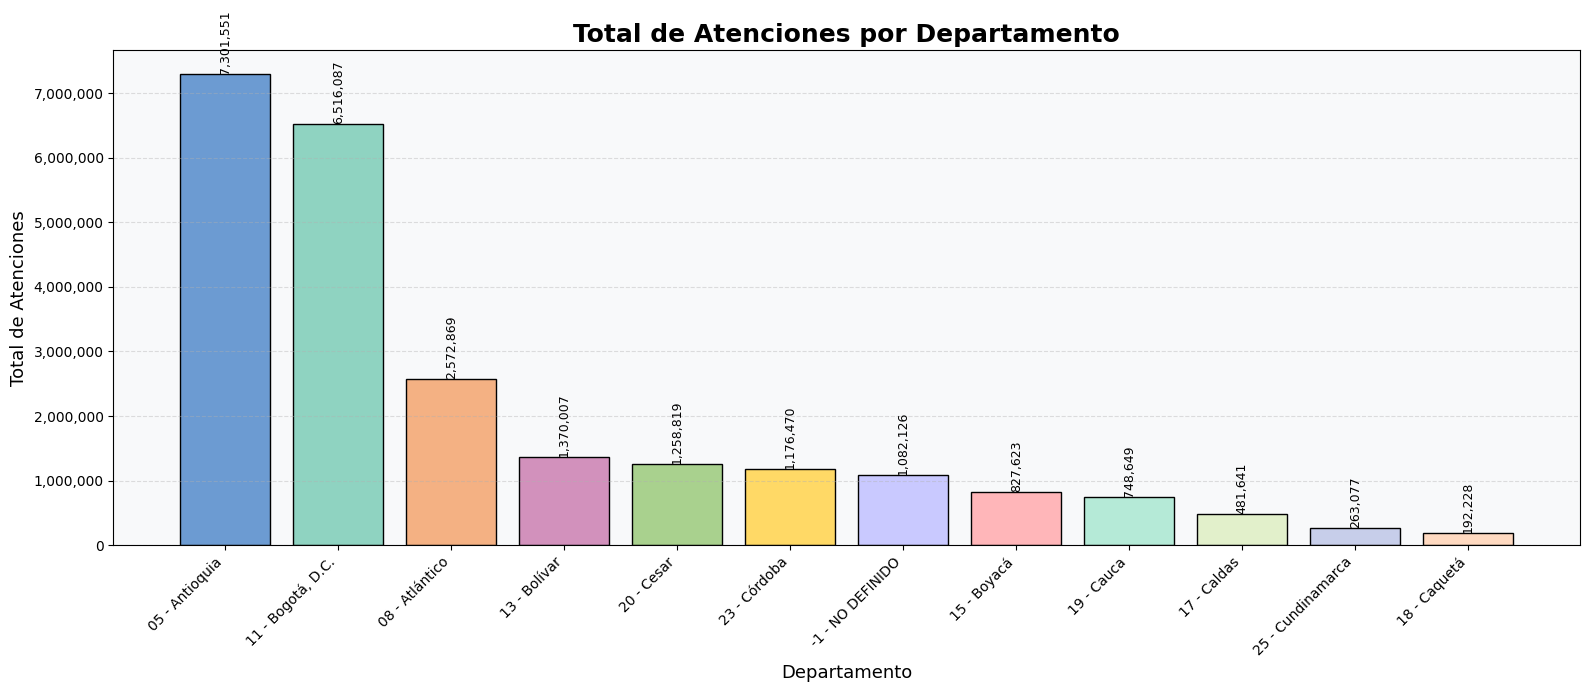

In [39]:

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Convertir a Pandas
depto_pd = depto_group.toPandas()

depto_pd = depto_pd.sort_values(
    by="total_atenciones",
    ascending=False
)


plt.figure(figsize=(16,7))

colores = [
    "#6C9BD2",
    "#8FD3C1",
    "#F4B183",
    "#D291BC",
    "#A9D18E",
    "#FFD966",
    "#C9C9FF",
    "#FFB6B9",
    "#B5EAD7",
    "#E2F0CB",
    "#C7CEEA",
    "#FFDAC1"
]

bars = plt.bar(
    depto_pd["departamento"],
    depto_pd["total_atenciones"],
    color=colores[:len(depto_pd)],
    edgecolor="black",
    linewidth=1
)


for bar in bars:

    altura = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        altura,
        f'{altura:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9,
        rotation=90
    )

plt.title(
    "Total de Atenciones por Departamento",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel(
    "Departamento",
    fontsize=13
)

plt.ylabel(
    "Total de Atenciones",
    fontsize=13
)

plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{int(x):,}')
)

plt.xticks(
    rotation=45,
    ha='right',
    fontsize=10
)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)

plt.gca().set_facecolor('#F8F9FA')

plt.tight_layout()

plt.show()



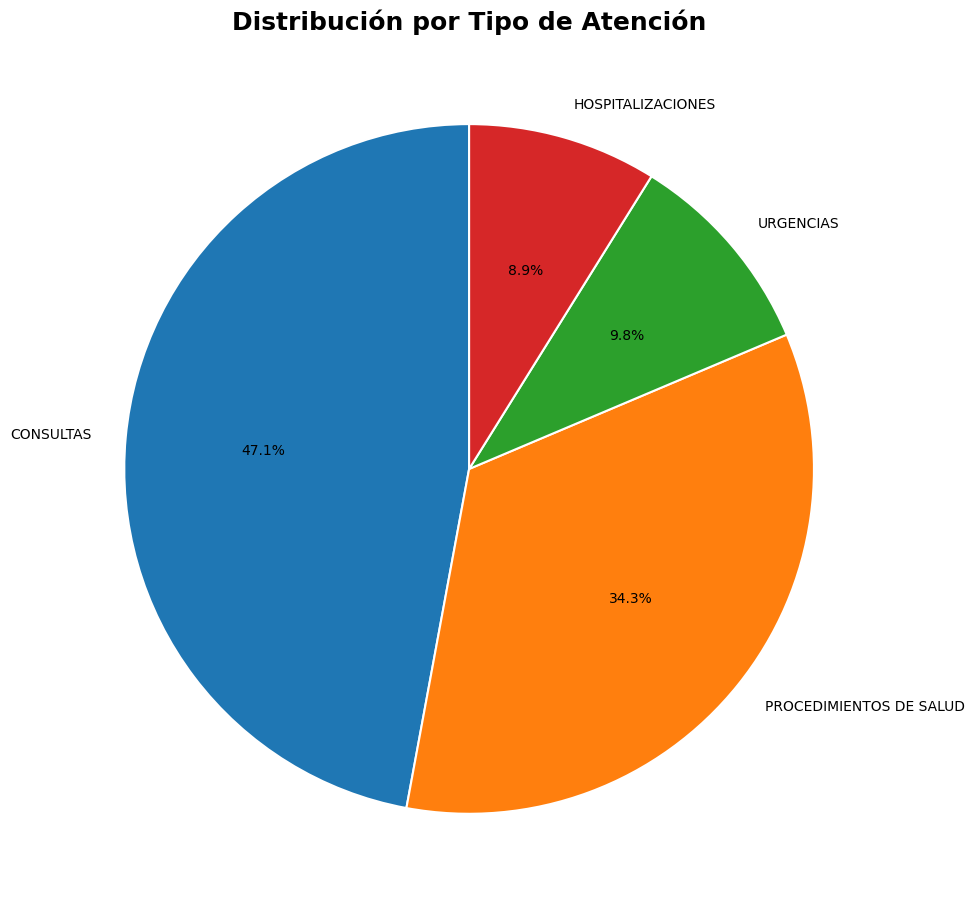

In [42]:

import matplotlib.pyplot as plt

tipo_pd = conteo_tipo.toPandas()

tipo_pd = tipo_pd.sort_values(
    by="count",
    ascending=False
)

plt.figure(figsize=(10,10))

plt.pie(
    tipo_pd["count"],
    labels=tipo_pd["tipoatencion"],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

plt.title(
    "Distribución por Tipo de Atención",
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()

plt.show()



# 1.6 Redactar tres conclusiones cuantitativas que respondan a preguntas analíticas del dominio del dato

 ---
 - Los departamentos con mayor volumen de registros concentran una proporción significativa de las atenciones médicas, evidenciando desigualdades regionales en la demanda de servicios de salud.

---

 - La distribución de la variable numeroatenciones presenta asimetría positiva, indicando que la mayoría de registros tienen pocas atenciones, mientras unos pocos presentan valores extremadamente altos.

---


- La detección de valores atípicos mostró registros muy superiores al comportamiento promedio, lo cual puede estar asociado a eventos epidemiológicos, errores de captura o municipios con alta concentración poblacional.
---
